In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import MinMaxScaler
import joblib
import json
import warnings
from collections import Counter
warnings.filterwarnings("ignore")

DATA_DIR  = Path("../data/processed/FD001")
RAW_DIR   = Path("../data/raw")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FEATURE_COLS = [
    "op1","op2",
    "s2","s3","s4","s7","s8","s9",
    "s11","s12","s13","s14","s15","s17","s20","s21",
]
CLASS_NAMES = ["C0 healthy", "C1 early", "C2 advanced", "C3 imminent"]
NUM_CLASSES = 4
SEQ_LEN     = 30
INPUT_DIM   = 16

COLUMNS = (
    ["engine_id", "cycle"]
    + [f"op{i}" for i in range(1, 4)]
    + [f"s{i}"  for i in range(1, 22)]
)
DROP_COLS    = ["s1","s5","s6","s10","s16","s18","s19","op3"]
GLOBAL_SCALE = ["s3"]
PER_ENGINE   = [f for f in FEATURE_COLS if f not in GLOBAL_SCALE]

print(f"Device : {DEVICE}")
print(f"INPUT_DIM : {INPUT_DIM}, SEQ_LEN : {SEQ_LEN}")

Device : cpu
INPUT_DIM : 16, SEQ_LEN : 30


In [2]:
class FaultClassifier1DCNN(nn.Module):
    def __init__(self, input_dim, seq_len, num_classes):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(input_dim, 64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64,        128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv_block(x)
        return self.classifier(x)


model = FaultClassifier1DCNN(INPUT_DIM, SEQ_LEN, NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(DATA_DIR / "classifier_1dcnn.pt", map_location=DEVICE))
model.eval()
print("Classifier loaded.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Classifier loaded.
Parameters: 307,332


In [3]:
def load_cmapss(path):
    df = pd.read_csv(path, sep=r"\s+", header=None)
    df = df.iloc[:, :len(COLUMNS)]
    df.columns = COLUMNS
    df = df.apply(pd.to_numeric, errors="coerce")
    return df


def preprocess_unseen(df):
    """
    For FD002-FD004 we have no saved per-engine scalers.
    Apply global scaler (saved from FD001) for s3.
    Fit fresh per-engine scaler for remaining features.
    This is the correct approach for cross-dataset evaluation.
    """
    df = df.copy()
    df = df.drop(columns=DROP_COLS, errors="ignore")

    # global scaler for s3 — use FD001 fitted scaler
    df[GLOBAL_SCALE] = global_scaler.transform(df[GLOBAL_SCALE])

    scaled_parts = []
    for engine_id, group in df.groupby("engine_id"):
        group  = group.copy()
        scaler = MinMaxScaler()
        group[PER_ENGINE] = scaler.fit_transform(group[PER_ENGINE])
        scaled_parts.append(group)

    return pd.concat(scaled_parts).sort_values(
        ["engine_id","cycle"]
    ).reset_index(drop=True)


def get_last_window(df, window_size=30):
    X_test, engine_ids = [], []
    for engine_id, group in df.groupby("engine_id"):
        group = group.sort_values("cycle")
        feats = group[FEATURE_COLS].values
        if len(feats) >= window_size:
            window = feats[-window_size:]
        else:
            pad    = np.zeros((window_size - len(feats), feats.shape[1]))
            window = np.vstack([pad, feats])
        X_test.append(window)
        engine_ids.append(engine_id)
    return np.array(X_test, dtype=np.float32), engine_ids


def rul_to_class(rul):
    if rul > 100: return 0
    elif rul > 50: return 1
    elif rul > 10: return 2
    else: return 3


def evaluate_subset(subset, model, device):
    """Full pipeline: load → preprocess → window → predict → evaluate."""
    print(f"\n{'='*50}")
    print(f"Evaluating on {subset}")
    print(f"{'='*50}")

    test_raw = load_cmapss(RAW_DIR / f"test_{subset}.txt")
    test_df  = preprocess_unseen(test_raw)

    rul_df   = pd.read_csv(RAW_DIR / f"RUL_{subset}.txt",
                           header=None, names=["RUL"])
    rul_df["engine_id"] = range(1, len(rul_df)+1)

    X_test, engine_ids = get_last_window(test_df, window_size=SEQ_LEN)
    y_test_rul = rul_df["RUL"].values
    y_test     = np.array([rul_to_class(r) for r in y_test_rul], dtype=np.int64)

    print(f"Engines     : {len(engine_ids)}")
    print(f"Class dist  : {Counter(y_test.tolist())}")

    # predict
    X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(X_tensor)
        preds  = logits.argmax(dim=1).cpu().numpy()

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="weighted", zero_division=0)

    # RUL RMSE
    CLASS_RUL_MIDPOINT = {0: 125, 1: 75, 2: 30, 3: 5}
    pred_rul = np.array([CLASS_RUL_MIDPOINT[c] for c in preds])
    rmse     = np.sqrt(np.mean((pred_rul - y_test_rul) ** 2))

    print(f"\nAccuracy    : {acc:.4f}")
    print(f"F1 weighted : {f1:.4f}")
    print(f"RUL RMSE    : {rmse:.2f}")
    print()
    print(classification_report(y_test, preds,
                                 target_names=CLASS_NAMES,
                                 zero_division=0))

    return {
        "subset"    : subset,
        "n_engines" : len(engine_ids),
        "accuracy"  : round(float(acc),  4),
        "f1"        : round(float(f1),   4),
        "rul_rmse"  : round(float(rmse), 2),
        "y_true"    : y_test,
        "y_pred"    : preds,
        "class_dist": Counter(y_test.tolist()),
    }


# load global scaler from FD001
global_scaler = joblib.load(DATA_DIR / "global_scaler.pkl")
print("Global scaler loaded.")

Global scaler loaded.


In [4]:
results = {}

# FD001 baseline — use saved engine scalers
def evaluate_fd001(model, device):
    engine_scalers = joblib.load(DATA_DIR / "engine_scalers.pkl")

    test_raw = load_cmapss(RAW_DIR / "test_FD001.txt")
    test_df  = test_raw.copy().drop(columns=DROP_COLS, errors="ignore")

    test_df[GLOBAL_SCALE] = global_scaler.transform(test_df[GLOBAL_SCALE])
    scaled_parts = []
    for engine_id, group in test_df.groupby("engine_id"):
        group = group.copy()
        if engine_id in engine_scalers:
            group[PER_ENGINE] = engine_scalers[engine_id].transform(group[PER_ENGINE])
        else:
            group[PER_ENGINE] = MinMaxScaler().fit_transform(group[PER_ENGINE])
        scaled_parts.append(group)
    test_df = pd.concat(scaled_parts).sort_values(["engine_id","cycle"]).reset_index(drop=True)

    rul_df  = pd.read_csv(RAW_DIR / "RUL_FD001.txt", header=None, names=["RUL"])
    rul_df["engine_id"] = range(1, len(rul_df)+1)

    X_test, engine_ids = get_last_window(test_df, window_size=SEQ_LEN)
    y_test_rul = rul_df["RUL"].values
    y_test     = np.array([rul_to_class(r) for r in y_test_rul], dtype=np.int64)

    X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model(X_tensor).argmax(dim=1).cpu().numpy()

    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds, average="weighted", zero_division=0)
    rmse = np.sqrt(np.mean((
        np.array([{0:125,1:75,2:30,3:5}[c] for c in preds]) - y_test_rul
    )**2))

    print(f"\n{'='*50}")
    print(f"Evaluating on FD001 (baseline)")
    print(f"{'='*50}")
    print(f"Accuracy    : {acc:.4f}")
    print(f"F1 weighted : {f1:.4f}")
    print(f"RUL RMSE    : {rmse:.2f}")
    print(classification_report(y_test, preds, target_names=CLASS_NAMES, zero_division=0))

    return {"subset":"FD001","n_engines":len(engine_ids),
            "accuracy":round(float(acc),4),"f1":round(float(f1),4),
            "rul_rmse":round(float(rmse),2),"y_true":y_test,"y_pred":preds,
            "class_dist":Counter(y_test.tolist())}

results["FD001"] = evaluate_fd001(model, DEVICE)


Evaluating on FD001 (baseline)
Accuracy    : 0.5600
F1 weighted : 0.5574
RUL RMSE    : 36.54
              precision    recall  f1-score   support

  C0 healthy       0.53      0.70      0.61        33
    C1 early       0.57      0.38      0.46        34
 C2 advanced       0.87      0.50      0.63        26
 C3 imminent       0.37      1.00      0.54         7

    accuracy                           0.56       100
   macro avg       0.58      0.64      0.56       100
weighted avg       0.62      0.56      0.56       100



In [5]:
for subset in ["FD002", "FD003", "FD004"]:
    try:
        results[subset] = evaluate_subset(subset, model, DEVICE)
    except FileNotFoundError:
        print(f"{subset}: test file not found in {RAW_DIR} — skipping")


Evaluating on FD002
Engines     : 259
Class dist  : Counter({0: 92, 1: 79, 2: 66, 3: 22})

Accuracy    : 0.0849
F1 weighted : 0.0133
RUL RMSE    : 93.25

              precision    recall  f1-score   support

  C0 healthy       0.00      0.00      0.00        92
    C1 early       0.00      0.00      0.00        79
 C2 advanced       0.00      0.00      0.00        66
 C3 imminent       0.08      1.00      0.16        22

    accuracy                           0.08       259
   macro avg       0.02      0.25      0.04       259
weighted avg       0.01      0.08      0.01       259


Evaluating on FD003
Engines     : 100
Class dist  : Counter({1: 39, 0: 32, 2: 23, 3: 6})

Accuracy    : 0.1400
F1 weighted : 0.1257
RUL RMSE    : 67.85

              precision    recall  f1-score   support

  C0 healthy       0.50      0.03      0.06        32
    C1 early       0.50      0.10      0.17        39
 C2 advanced       0.11      0.17      0.13        23
 C3 imminent       0.10      0.83      

In [6]:
summary_rows = []
for subset, res in results.items():
    summary_rows.append({
        "Subset"    : subset,
        "Engines"   : res["n_engines"],
        "Accuracy"  : res["accuracy"],
        "F1"        : res["f1"],
        "RUL RMSE"  : res["rul_rmse"],
    })

summary_df = pd.DataFrame(summary_rows)
print("\nCROSS DATASET EVALUATION SUMMARY")
print("=" * 55)
print(summary_df.to_string(index=False))
print("=" * 55)
print("\nFD001: single fault, 1 op condition  (trained on this)")
print("FD002: single fault, 6 op conditions (unseen)")
print("FD003: multi fault,  1 op condition  (unseen)")
print("FD004: multi fault,  6 op conditions (unseen — hardest)")


CROSS DATASET EVALUATION SUMMARY
Subset  Engines  Accuracy     F1  RUL RMSE
 FD001      100    0.5600 0.5574     36.54
 FD002      259    0.0849 0.0133     93.25
 FD003      100    0.1400 0.1257     67.85
 FD004      248    0.0565 0.0060     98.10

FD001: single fault, 1 op condition  (trained on this)
FD002: single fault, 6 op conditions (unseen)
FD003: multi fault,  1 op condition  (unseen)
FD004: multi fault,  6 op conditions (unseen — hardest)


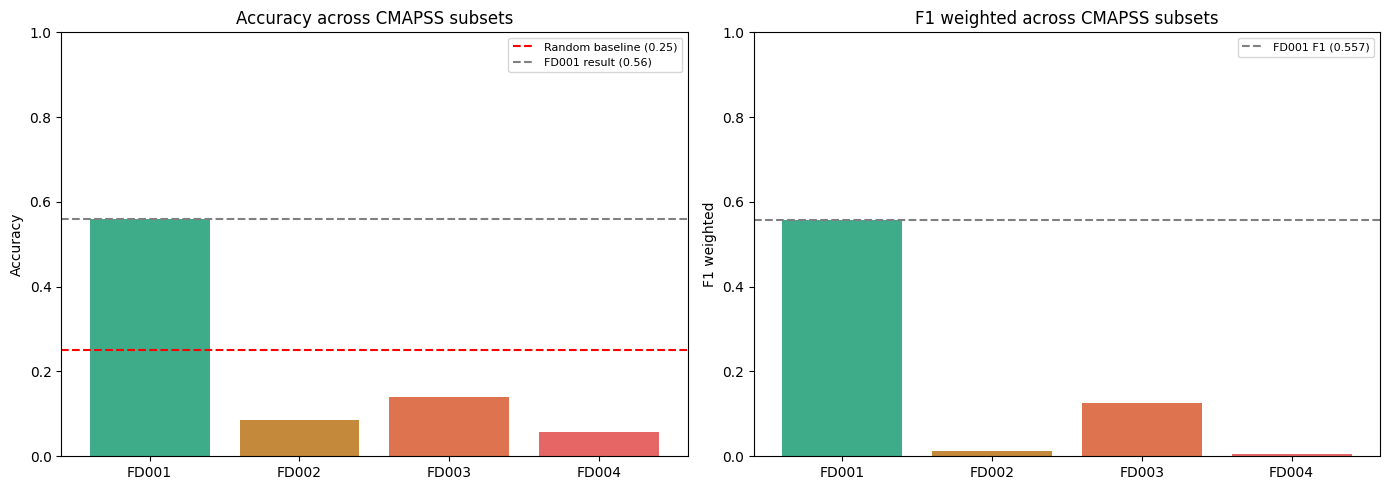

In [7]:
subsets   = list(results.keys())
accs      = [results[s]["accuracy"] for s in subsets]
f1s       = [results[s]["f1"]       for s in subsets]
colors    = ["#1D9E75", "#BA7517", "#D85A30", "#E24B4A"][:len(subsets)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(subsets, accs, color=colors, alpha=0.85)
axes[0].axhline(0.25, color="red",  linestyle="--", label="Random baseline (0.25)")
axes[0].axhline(0.56, color="gray", linestyle="--", label="FD001 result (0.56)")
axes[0].set_title("Accuracy across CMAPSS subsets")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

axes[1].bar(subsets, f1s, color=colors, alpha=0.85)
axes[1].axhline(0.5574, color="gray", linestyle="--", label="FD001 F1 (0.557)")
axes[1].set_title("F1 weighted across CMAPSS subsets")
axes[1].set_ylabel("F1 weighted")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../reports/figures/cross_dataset_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("C3 IMMINENT FAILURE RECALL per subset")
print("(most safety-critical metric)")
print("=" * 40)

for subset, res in results.items():
    y_true = res["y_true"]
    y_pred = res["y_pred"]
    c3_mask = y_true == 3
    if c3_mask.sum() == 0:
        print(f"  {subset}: no C3 engines in test set")
        continue
    c3_recall = (y_pred[c3_mask] == 3).mean()
    print(f"  {subset}: C3 recall={c3_recall:.2f}  "
          f"(n={c3_mask.sum()}, detected={( y_pred[c3_mask]==3).sum()})")

C3 IMMINENT FAILURE RECALL per subset
(most safety-critical metric)
  FD001: C3 recall=1.00  (n=7, detected=7)
  FD002: C3 recall=1.00  (n=22, detected=22)
  FD003: C3 recall=0.83  (n=6, detected=5)
  FD004: C3 recall=1.00  (n=14, detected=14)


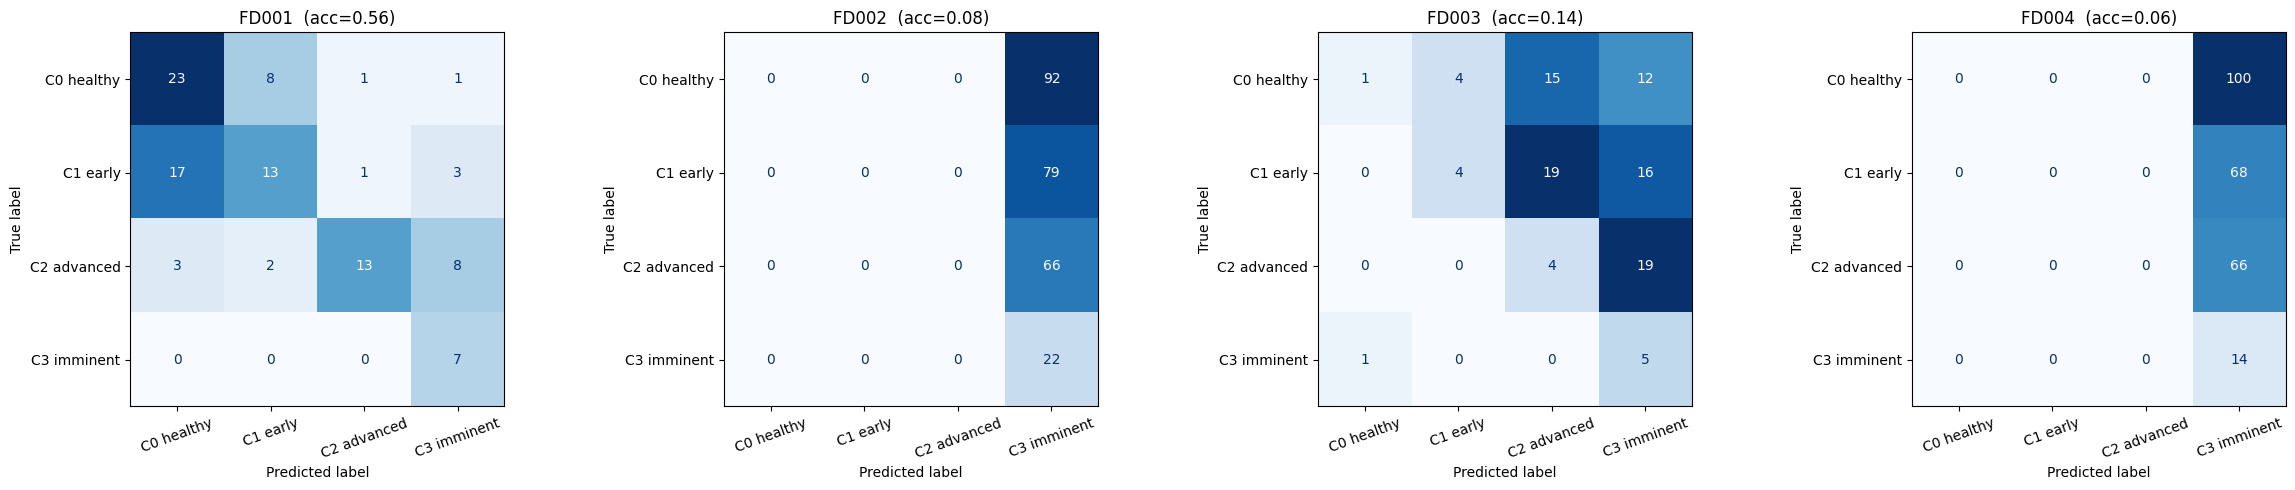

In [9]:
n_subsets = len(results)
fig, axes = plt.subplots(1, n_subsets, figsize=(6 * n_subsets, 5))

if n_subsets == 1:
    axes = [axes]

for ax, (subset, res) in zip(axes, results.items()):
    cm   = confusion_matrix(res["y_true"], res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{subset}  (acc={res['accuracy']:.2f})")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../reports/figures/cross_dataset_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [10]:
save_results = {}
for subset, res in results.items():
    save_results[subset] = {
        "n_engines": res["n_engines"],
        "accuracy" : res["accuracy"],
        "f1"       : res["f1"],
        "rul_rmse" : res["rul_rmse"],
    }

with open(DATA_DIR / "phase9_cross_dataset_results.json", "w") as f:
    json.dump(save_results, f, indent=2)

print("Saved phase9_cross_dataset_results.json")
print("\nFINAL CROSS DATASET SUMMARY")
print("=" * 55)
for subset, res in save_results.items():
    print(f"  {subset}  acc={res['accuracy']:.4f}  "
          f"f1={res['f1']:.4f}  rmse={res['rul_rmse']:.2f}")
print("=" * 55)

Saved phase9_cross_dataset_results.json

FINAL CROSS DATASET SUMMARY
  FD001  acc=0.5600  f1=0.5574  rmse=36.54
  FD002  acc=0.0849  f1=0.0133  rmse=93.25
  FD003  acc=0.1400  f1=0.1257  rmse=67.85
  FD004  acc=0.0565  f1=0.0060  rmse=98.10


In [11]:
import pandas as pd
from pathlib import Path

for subset in ["FD002", "FD004"]:
    df = pd.read_csv(
        Path("../data/raw") / f"train_{subset}.txt",
        sep=r"\s+", header=None
    ).iloc[:, :5]
    df.columns = ["engine_id","cycle","op1","op2","op3"]
    print(f"{subset} op1 unique: {df['op1'].nunique()}")
    print(f"{subset} op2 unique: {df['op2'].nunique()}")
    print(f"{subset} op3 unique: {df['op3'].nunique()}")
    print()

FD002 op1 unique: 536
FD002 op2 unique: 105
FD002 op3 unique: 2

FD004 op1 unique: 536
FD004 op2 unique: 105
FD004 op3 unique: 2

